In [2]:
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

#consts
sizeOfPlot = (16,7)


def alphaCalc(N):
    return 2 / (N + 1)

data = pd.read_csv('Data.csv')


In [4]:
def subArrays(arr1, arr2):
    resultArr = []
    length = len(arr1)
    if len(arr2)<length:
        length = len(arr2)
    for i in range(0, length):
        resultArr.append(arr1[i]-arr2[i])
    return resultArr

In [5]:
def EMA_element_calc(data, N, id_of_curr_elem):
    """
    Calculates EMA of N elements starting from data[id_of_curr_elem], goes backwards
    
    Arguments:
    data - input array
    N - number of elements
    id_of_curr_elem - id of start in input array
    """
    
    OneMinusAlpha=1-alphaCalc(N)
    emaNumerator = data[id_of_curr_elem]
    emaDenominator =1
    for i in range(1, min(N, id_of_curr_elem+1)):
        emaNumerator+=(OneMinusAlpha**i)*data[id_of_curr_elem-i]
        emaDenominator+=OneMinusAlpha**i
    return emaNumerator/emaDenominator


In [6]:
def EMA_calc(data, N):
    EMAs_array = []
    for i in range(0,len(data)): #through all numbers
        emaElem = EMA_element_calc(data, N, i)
        EMAs_array.append(emaElem)
    return EMAs_array


In [7]:
def toFloats(array):
    float_array = []
    for i in array:
        item = float(i.replace(',',''))
        float_array.append(item)
    return float_array

In [8]:
def intersectionPoints(MACD, SIGNAL): 
    """Finds points of intersection and return three array: intersection, buy and sell
    buy and sell are lists of tuples which containt (id, val)"""
    intersection = []
    buy = []
    sell = []
    for i in range(1, len(MACD)-1): #skip first because there is no way to analyse if it would be buy or sell
       
        if MACD[i-1] < SIGNAL[i-1] and MACD[i] > SIGNAL[i]:
            intersection.append(i) #add id in MACD array to intersection array
            buy.append((i,MACD[i]))
        elif MACD[i-1] > SIGNAL[i-1] and MACD[i] < SIGNAL[i]:
            intersection.append(i)
            sell.append((i,MACD[i]))       
    return intersection, buy, sell


In [9]:
def extractFromTuple(tupleArr, index):
    arrRes = []
    for i in tupleArr:
        arrRes.append(i[index])
    return arrRes

In [10]:
def getArrayOfIndexes(entry, indexArr):
    result = []
    for i in indexArr:
        result.append(entry[i])
    return result

In [11]:
data_from_csv = pd.read_csv('Data.csv')
data_for_calc = data_from_csv['Close']
data_for_calc = data_for_calc.tolist()
data_for_calc = data_for_calc[::-1]

dates = pd.to_datetime(data_from_csv['Data'], format='%Y-%m-%d')
dates=dates.tolist()
dates = dates[::-1]

In [12]:
#data_for_calc = toFloats(data_for_calc)


In [13]:
EMA12 = EMA_calc(data_for_calc, 12)
EMA26 = EMA_calc(data_for_calc,26)
MACD = subArrays(EMA12,EMA26)
SIGNAL = EMA_calc(MACD,9)

In [14]:
intersectPoints, buyArray, sellArray = intersectionPoints(MACD, SIGNAL)

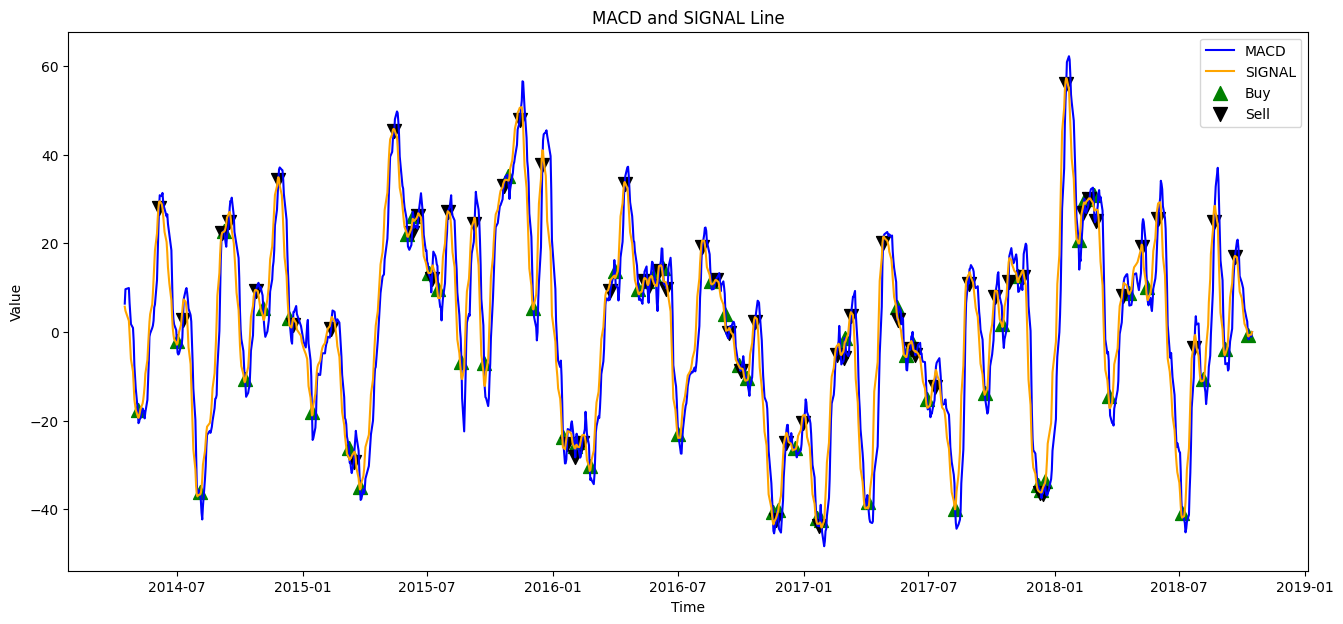

In [15]:
plt.figure(figsize=sizeOfPlot)
plt.plot(dates,MACD, label='MACD', color='blue') 
plt.plot(dates,SIGNAL, label='SIGNAL', color='orange')

buyPoints = getArrayOfIndexes(dates, extractFromTuple(buyArray,0))
buyValues = extractFromTuple(buyArray,1)
sellPoints = getArrayOfIndexes(dates, extractFromTuple(sellArray,0))
sellValues = extractFromTuple(sellArray,1)

plt.scatter(buyPoints, buyValues, color='green', marker='^', label='Buy', s=100)
plt.scatter(sellPoints, sellValues, color='black', marker='v', label='Sell', s = 100)

plt.legend(loc='upper right')
plt.title('MACD and SIGNAL Line')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()


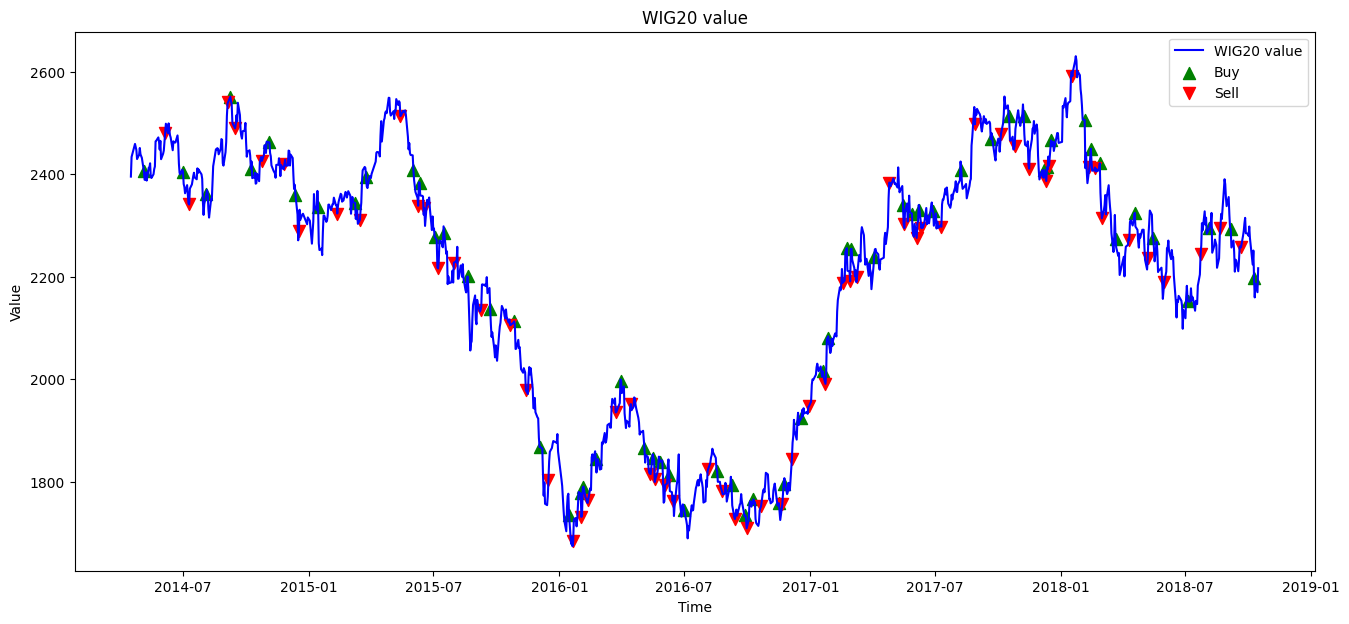

In [16]:
plt.figure(figsize=sizeOfPlot)
plt.plot(dates,data_for_calc,label='WIG20 value', color='blue')

buyPoints = [point[0] for point in buyArray]
buyValues = getArrayOfIndexes(data_for_calc,buyPoints) 
buyPoints = getArrayOfIndexes(dates, extractFromTuple(buyArray,0))
sellPoints = [point[0] for point in sellArray]
sellValues = getArrayOfIndexes(data_for_calc, sellPoints)
sellPoints = getArrayOfIndexes(dates, extractFromTuple(sellArray,0))


plt.scatter(buyPoints, buyValues, color='green', marker='^', label='Buy', s=75)
plt.scatter(sellPoints, sellValues, color='red', marker='v', label='Sell', s=75)
plt.legend(loc='upper right')

plt.title('WIG20 value')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

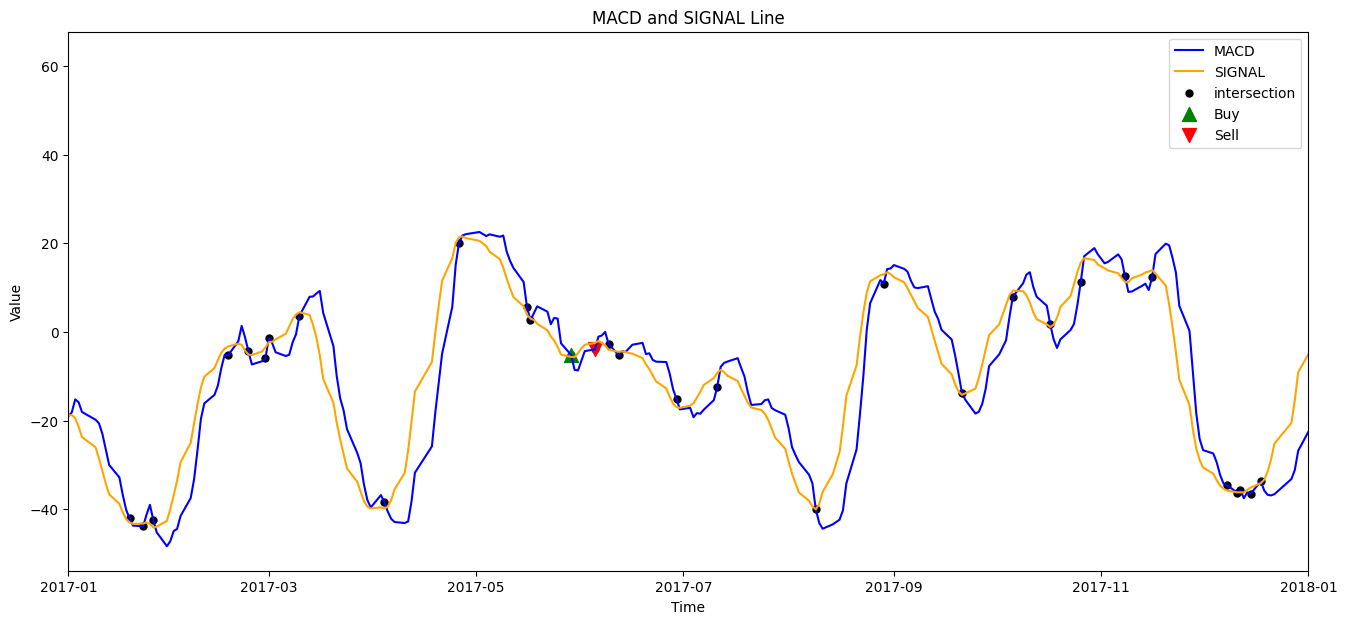

In [17]:
#plot MACD and SIGNAL for 3.2.1

plt.figure(figsize=sizeOfPlot)
plt.plot(dates,MACD, label='MACD', color='blue') 
plt.plot(dates,SIGNAL, label='SIGNAL', color='orange')

plt.xlim(pd.to_datetime('2017-01-01'),pd.to_datetime('2018-01-01'))

checkedIndex = 19

buyPoints = getArrayOfIndexes(dates, extractFromTuple(buyArray,0))
buyPoints = buyPoints[checkedIndex]
buyValues = extractFromTuple(buyArray,1)
buyValues = buyValues[checkedIndex]
sellPoints = getArrayOfIndexes(dates, extractFromTuple(sellArray,0))
sellPoints = sellPoints[checkedIndex-1]
sellValues = extractFromTuple(sellArray,1)
sellValues = sellValues[checkedIndex-1]

interPoints = getArrayOfIndexes(dates, intersectPoints)
interValues = getArrayOfIndexes(MACD, intersectPoints)

plt.scatter(interPoints, interValues, color='black', marker='.', label='intersection', s=100)
plt.scatter(buyPoints, buyValues, color='green', marker='^', label='Buy', s=100)
plt.scatter(sellPoints, sellValues, color='red', marker='v', label='Sell', s = 100)


plt.legend(loc='upper right')
plt.title('MACD and SIGNAL Line')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

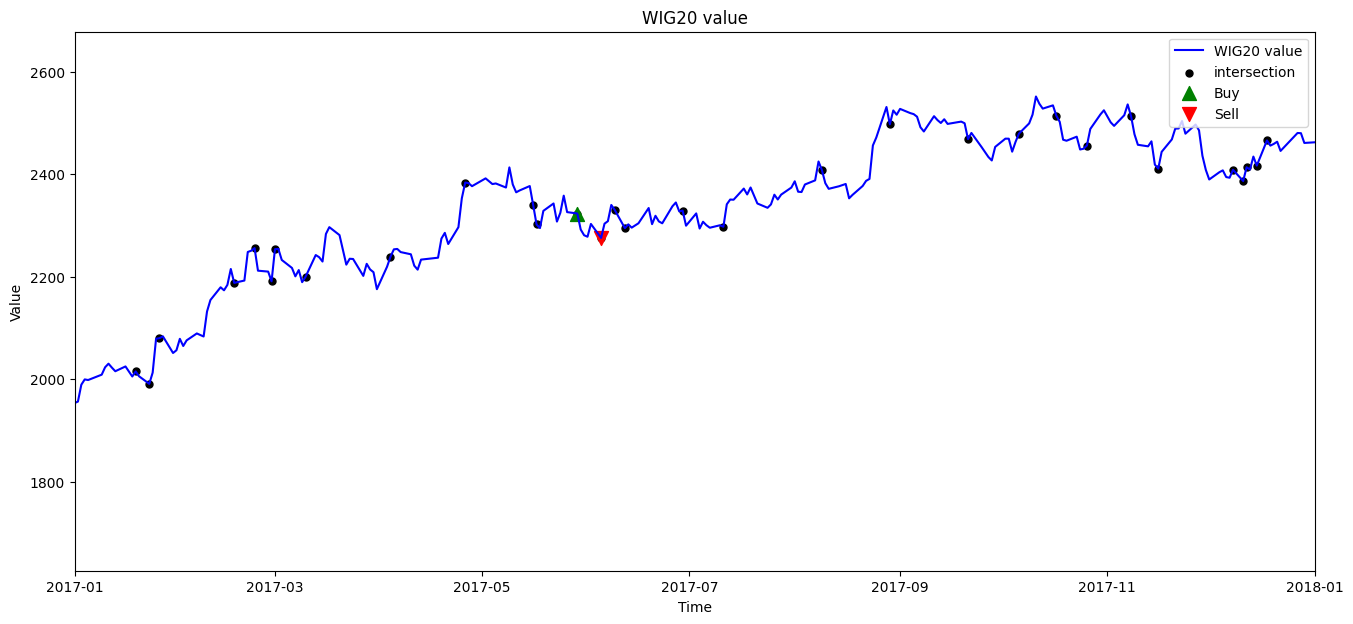

In [18]:
#plot of prices for 3.2.1


plt.figure(figsize=sizeOfPlot)
plt.plot(dates,data_for_calc,label='WIG20 value', color='blue')

plt.xlim(pd.to_datetime('2017-01-01'),pd.to_datetime('2018-01-01'))

buyPoints = [point[0] for point in buyArray]
buyValues = getArrayOfIndexes(data_for_calc,buyPoints) 
buyPoints = getArrayOfIndexes(dates, extractFromTuple(buyArray,0))
buyPoints = buyPoints[checkedIndex]
buyValues = buyValues[checkedIndex]

sellPoints = [point[0] for point in sellArray]
sellValues = getArrayOfIndexes(data_for_calc, sellPoints)
sellPoints = getArrayOfIndexes(dates, extractFromTuple(sellArray,0))
sellPoints = sellPoints[checkedIndex-1]
sellValues = sellValues[checkedIndex-1]

interPoints = getArrayOfIndexes(dates, intersectPoints)
interValues = getArrayOfIndexes(data_for_calc, intersectPoints)

plt.scatter(interPoints, interValues, color='black', marker='.', label='intersection', s=100)
plt.scatter(buyPoints, buyValues, color='green', marker='^', label='Buy', s=100)
plt.scatter(sellPoints, sellValues, color='red', marker='v', label='Sell', s = 100)



plt.legend(loc='upper right')
plt.title('WIG20 value')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

In [19]:
print("Values of:")
print("buying: "+str(buyValues))
print("selling: "+str(sellValues))
print("zysk: "+str(round(sellValues-buyValues,2)))
print("Dates")
print("buying: "+str(buyPoints))
print("selling: "+str(sellPoints))

Values of:
buying: 2323.58
selling: 2276.01
zysk: -47.57
Dates
buying: 2017-05-29 00:00:00
selling: 2017-06-05 00:00:00


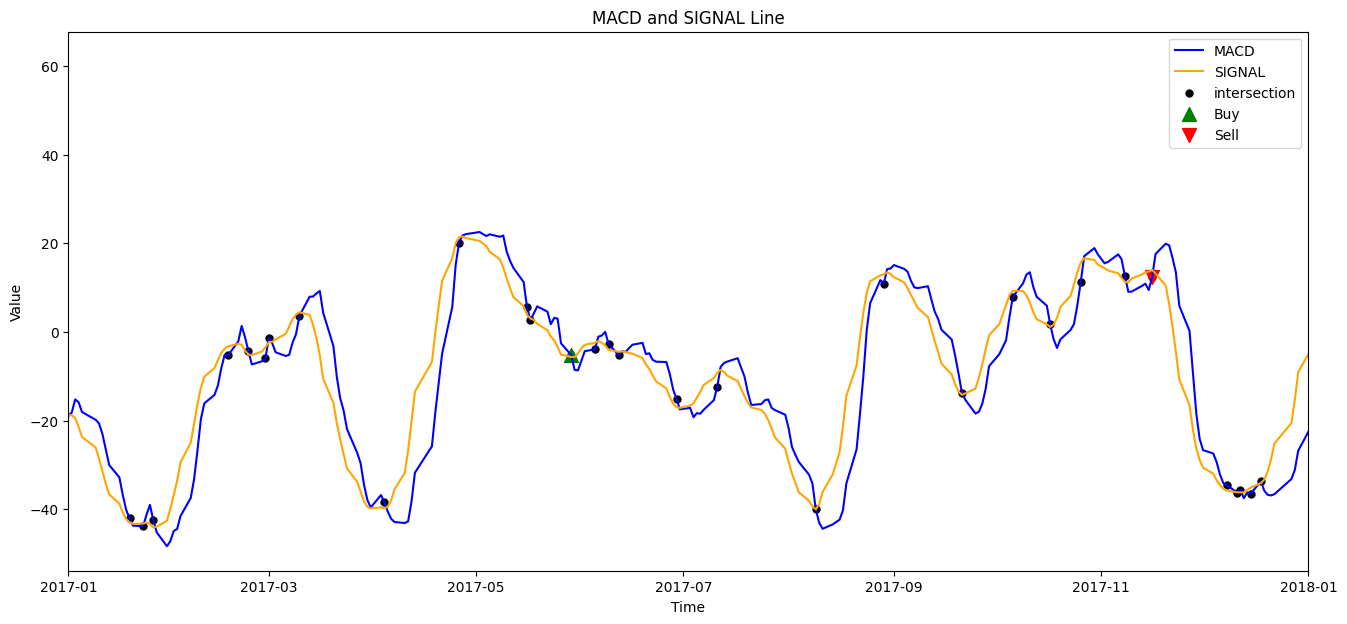

In [20]:
#plot MACD and SIGNAL for 3.2.2

plt.figure(figsize=sizeOfPlot)
plt.plot(dates,MACD, label='MACD', color='blue') 
plt.plot(dates,SIGNAL, label='SIGNAL', color='orange')

plt.xlim(pd.to_datetime('2017-01-01'),pd.to_datetime('2018-01-01'))

checkedIndex1 = 19
checkedIndex2 = 12

buyPoints = getArrayOfIndexes(dates, extractFromTuple(buyArray,0))
buyPoints = buyPoints[checkedIndex1]
buyValues = extractFromTuple(buyArray,1)
buyValues = buyValues[checkedIndex1]
sellPoints = getArrayOfIndexes(dates, extractFromTuple(sellArray,0))
sellPoints = sellPoints[checkedIndex2]
sellValues = extractFromTuple(sellArray,1)
sellValues = sellValues[checkedIndex2]

interPoints = getArrayOfIndexes(dates, intersectPoints)
interValues = getArrayOfIndexes(MACD, intersectPoints)

plt.scatter(interPoints, interValues, color='black', marker='.', label='intersection', s=100)
plt.scatter(buyPoints, buyValues, color='green', marker='^', label='Buy', s=100)
plt.scatter(sellPoints, sellValues, color='red', marker='v', label='Sell', s = 100)


plt.legend(loc='upper right')
plt.title('MACD and SIGNAL Line')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

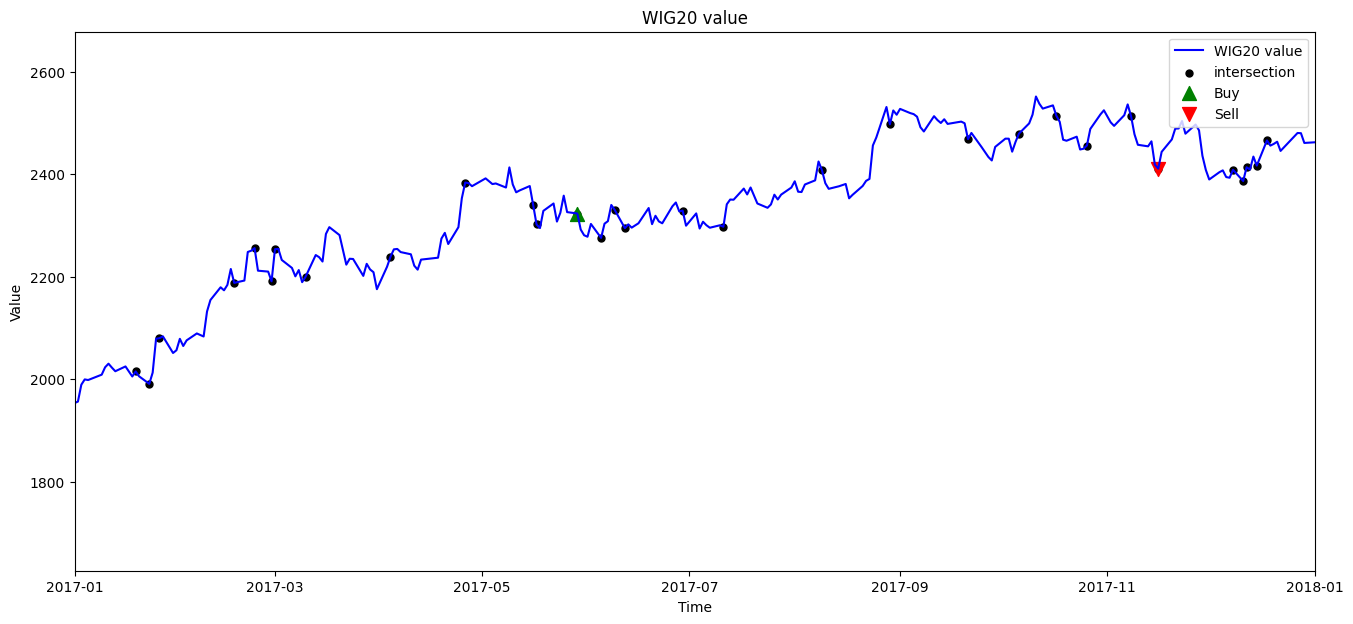

In [21]:
#plot of prices for 3.2.2


plt.figure(figsize=sizeOfPlot)
plt.plot(dates,data_for_calc,label='WIG20 value', color='blue')

plt.xlim(pd.to_datetime('2017-01-01'),pd.to_datetime('2018-01-01'))

buyPoints = [point[0] for point in buyArray]
buyValues = getArrayOfIndexes(data_for_calc,buyPoints) 
buyPoints = getArrayOfIndexes(dates, extractFromTuple(buyArray,0))
buyPoints = buyPoints[checkedIndex1]
buyValues = buyValues[checkedIndex1]

sellPoints = [point[0] for point in sellArray]
sellValues = getArrayOfIndexes(data_for_calc, sellPoints)
sellPoints = getArrayOfIndexes(dates, extractFromTuple(sellArray,0))
sellPoints = sellPoints[checkedIndex2]
sellValues = sellValues[checkedIndex2]

interPoints = getArrayOfIndexes(dates, intersectPoints)
interValues = getArrayOfIndexes(data_for_calc, intersectPoints)

plt.scatter(interPoints, interValues, color='black', marker='.', label='intersection', s=100)
plt.scatter(buyPoints, buyValues, color='green', marker='^', label='Buy', s=100)
plt.scatter(sellPoints, sellValues, color='red', marker='v', label='Sell', s = 100)



plt.legend(loc='upper right')
plt.title('WIG20 value')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

In [22]:
print("Values of:")
print("buying: "+str(buyValues))
print("selling: "+str(sellValues))
print("zysk: "+str(round(sellValues-buyValues,2)))
print("Dates")
print("buying: "+str(buyPoints))
print("selling: "+str(sellPoints))

Values of:
buying: 2323.58
selling: 2411.11
zysk: 87.53
Dates
buying: 2017-05-29 00:00:00
selling: 2017-11-16 00:00:00


In [ ]:
#Symulacja
simulationDays = len(data_for_calc)
sellPoints = [points[0] for points in sellArray]
buyPoints = [points[0] for points in buyArray]

PLN = 0 #starting value of account
stocks = 1000 #number of start stock actions 
isSelling =True #is next operation is operation of selling?

ops =("Sell", "Buy")
recordOfOperations = [{"PLN":PLN, "Stocks":stocks, "Operation":"Start",\
                       "Capital":data_for_calc[simulationDays-1]*stocks+PLN}]



for i in range(simulationDays-1, 0, -1):
    valueOfAction = data_for_calc[i]
    if isSelling and i in sellPoints:
        isSelling = False
        PLN+=round(stocks*valueOfAction,2)
        stocks =0
        PLN=round(PLN,2)
        recordOfOperations.append(\
            {"PLN":round(PLN,2), "Stocks":stocks, "Operation":ops[0],\
             "Capital":round(valueOfAction*stocks+PLN,2)})
    elif not isSelling and i in buyPoints:
        isSelling = True
        stocks+=int(PLN//valueOfAction)
        PLN-=stocks*valueOfAction #może nie być możliwe kupienie 
        #samych pełnych akcji
        PLN=round(PLN,2)
        recordOfOperations.append(\
            {"PLN":round(PLN,2), "Stocks":stocks, "Operation":ops[1],\
             "Capital":round(valueOfAction*stocks+PLN,2)})


recordInPandas = pd.DataFrame(recordOfOperations)
# Convert DataFrame to LaTeX table


recordInPandas.to_csv('simulation_result.csv', index=False)
latex_table = recordInPandas.to_latex(index=False,longtable=True, float_format=lambda x: f'{x:.2f}'.rstrip('0').rstrip('.'))

with open('record_of_operations_table.tex', 'w') as f:
    f.write(latex_table)



            PLN  Stocks Operation     Capital
0          0.00    1000     Start  2395550.00
1    2480850.00       0      Sell  2480850.00
2       1470.27    1031       Buy  2480850.00
3    2415226.85       0      Sell  2415226.85
4       1712.53    1022       Buy  2415226.85
..          ...     ...       ...         ...
116     1243.36     641       Buy  1472863.98
117  1472742.19       0      Sell  1472742.19
118      629.77     642       Buy  1472742.19
119  1449925.51       0      Sell  1449925.51
120     1878.45     659       Buy  1449925.51

[121 rows x 4 columns]


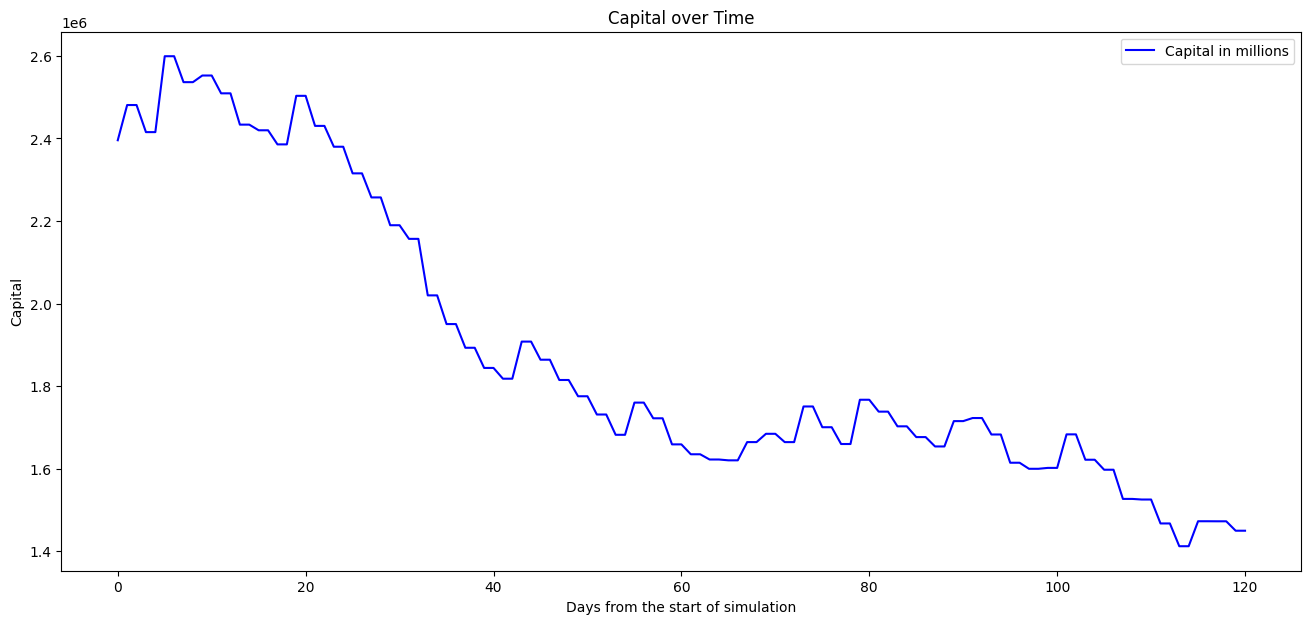

In [25]:


plt.figure(figsize=sizeOfPlot)



plt.plot( recordInPandas.index, recordInPandas["Capital"], label='Capital in millions', color='blue')
plt.legend(loc='upper right')
plt.title('Capital over Time')
plt.xlabel('Days from the start of simulation')
plt.ylabel('Capital')
plt.show()
